# qwen3.5:9b on MovieLens-1M — SCAFF audit results

The combination this project was missing: a served model deciding every stage, driven by
real user histories, scored against a real held-out reference.

**Run.** 150 users, 2 repeats, 9,680 model calls, no retries and no parse errors, about
eight hours on a local Ollama server. Every stage decision is one `/api/chat` call
constrained to a per-stage JSON schema, at temperature 0.7 so that the same-condition
noise floor is estimable.

**Two things to keep in view when reading these numbers.** Retrieve and Rank operate on a
shortlist of 40 films drawn by genre and training-half popularity, not the full 3,883-film
catalog, so the model is choosing within a shelf. And the planted fault reaches the model
as a prompt directive, so a miss still conflates a model that did not comply with an
estimator that did not detect; there is no manipulation check yet.

Produced by `scripts/run_ml1m_qwen_audit.py` and `scripts/analyze_ml1m_qwen.py`.

## 1. Localisation collapses when a real model replaces the scripted policy

Against the same planted faults the scripted policy scored 84.7%. qwen scores 32.7%.

rule                      accuracy   correct
argmax raw direct            18.0%    27/150
argmax direct - noise        32.7%    49/150
chance (six labels)          16.7%

errors naming the wrong stage: 88
missed detections:             13


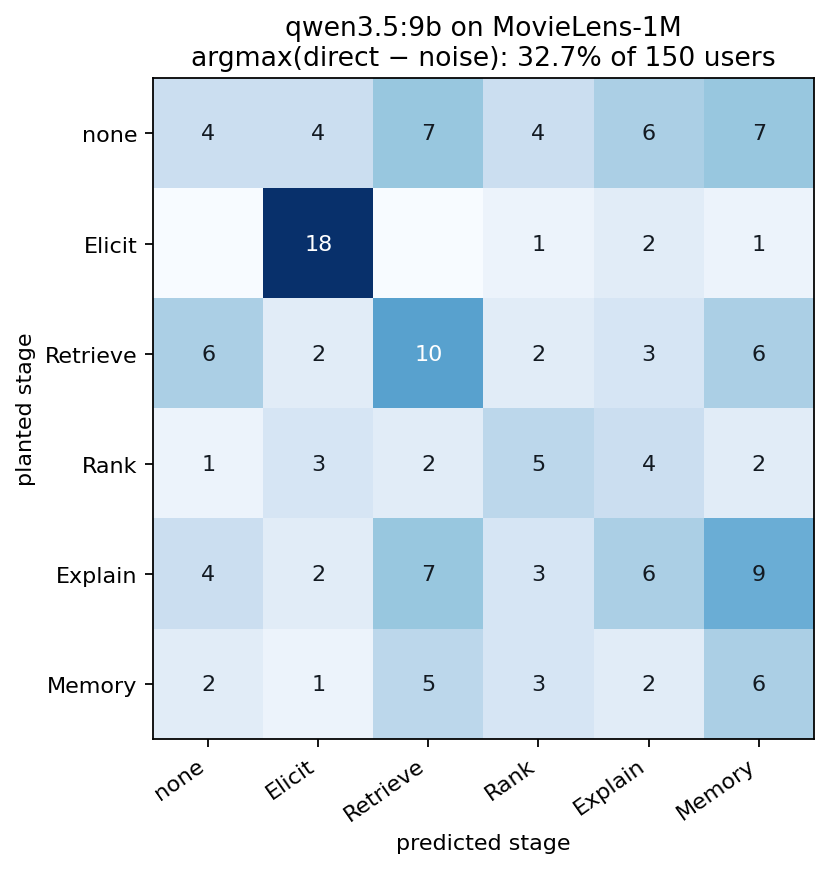

In [ ]:
# scripts/analyze_ml1m_qwen.py -- argmax over the noise-adjusted direct effect

The error profile changes, not just the rate. The scripted policy never named a wrong
stage; here 88 of the 101 errors do. Elicit is the one stage that still localises well
(18 of 22), which fits: it is the only stage whose output is short enough that a planted
instruction dominates the model's own variation.

## 2. Why: at an unplanted stage, the noise floor is as large as the effect

This figure is the result. A served model at temperature 0.7 moves its output about as
much between two identical runs as it does between two protected conditions.

rows                                    direct    noise   direct-noise
stage carrying the planted fault (236)  0.4496   0.2899        +0.1597
every other stage              (1264)   0.3668   0.3698        -0.0030

planted stages clearing their own noise floor: 163 of 236


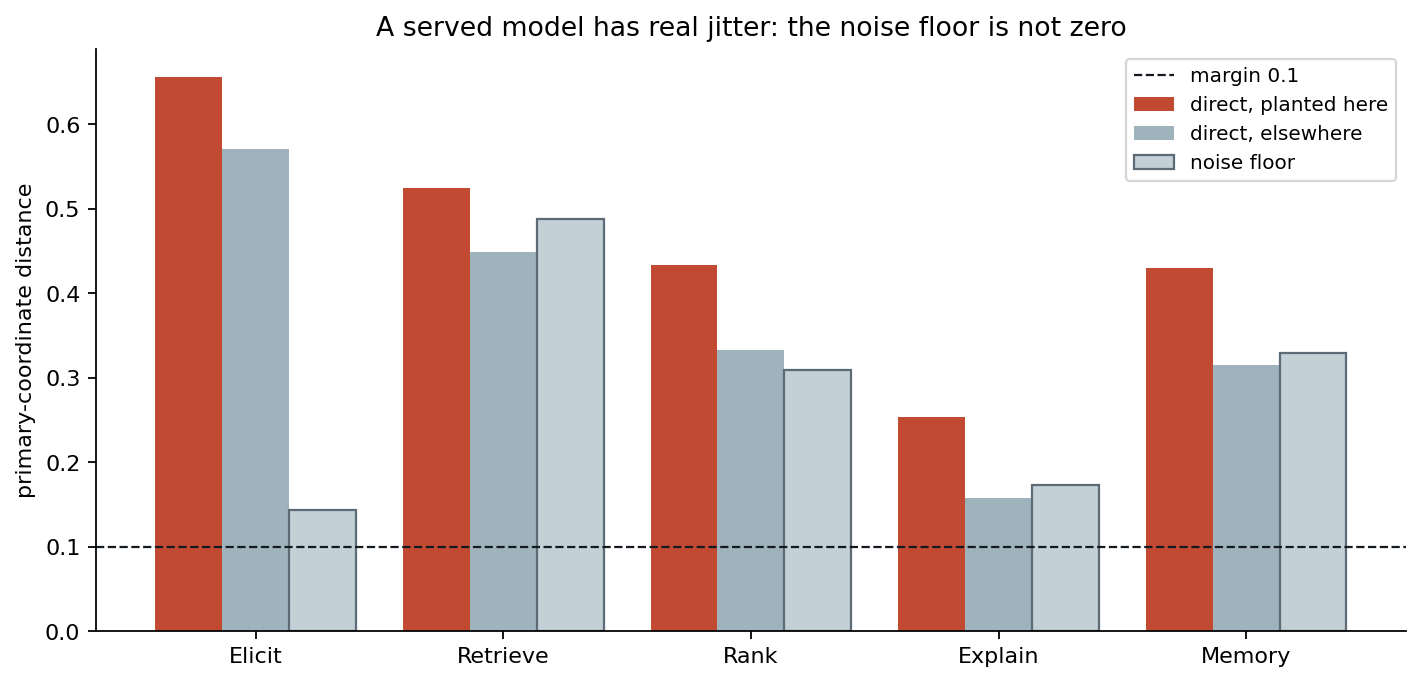

In [ ]:
# direct effect against each stage's own same-condition noise floor

The estimator is not broken, it is swamped. The planted stage still separates (+0.16
against the floor) and 163 of 236 planted stages clear their own floor. But an unplanted
stage sits at -0.003, meaning its apparent sensitivity is entirely jitter.

This is the clearest argument yet for making `direct - noise` the default decision rule:
subtracting the floor is worth 15 points of localisation accuracy here, and on the
synthetic qwen run it was worth 2 of 12.

## 3. Group dispersion

SNSR and SNSV per stage, against a neutral run with no attribute stated.

sim_item: mean SNSR 0.0353, max 0.0649
sim_pref: mean SNSR 0.0298, max 0.1205

SNSV = SNSR/2 identity:  sex 10/10 rows,  age 1/10 rows


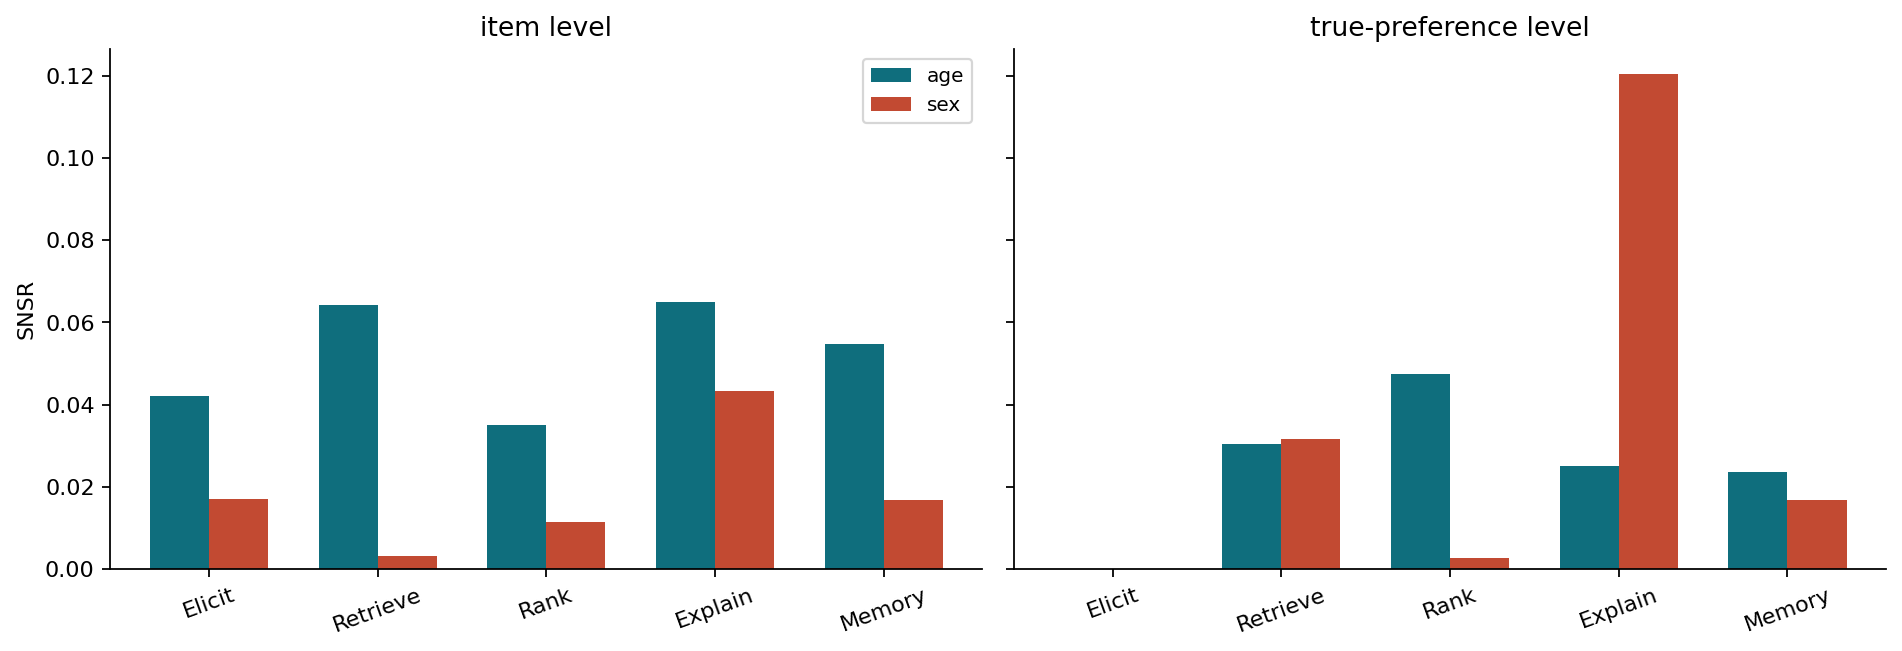

In [ ]:
# SNSR at both benefit levels

The binary identity holds exactly on all ten `sex` rows and breaks on nine of ten `age`
rows, which is the numerical proof of the caveat: SNSV earns its place only from three
attribute values up.

Unlike the synthetic runs, these dispersion values are not produced solely by the planted
faults, because the model reads the attribute field at every stage. They remain small
(max 0.12) and sit inside the jitter documented above, so they should not be read as
evidence that qwen treats these groups differently.

## 4. Sensitivity against consequence

          natural  direct  inherited   noise  benefit  benefit_neutral  benefit_delta
Elicit     0.6087  0.5837     0.5526  0.5368   0.1262           0.1262         0.0000
Retrieve   0.5403  0.4637     0.5308  0.4694   0.0289           0.0314        -0.0025
Rank       0.6148  0.3442     0.6182  0.3132   0.0348           0.0354        -0.0007
Explain    0.5722  0.1780     0.5577  0.1632   0.5157           0.5013         0.0144
Memory     0.6417  0.3297     0.6416  0.3036   0.5224           0.6785        -0.1526


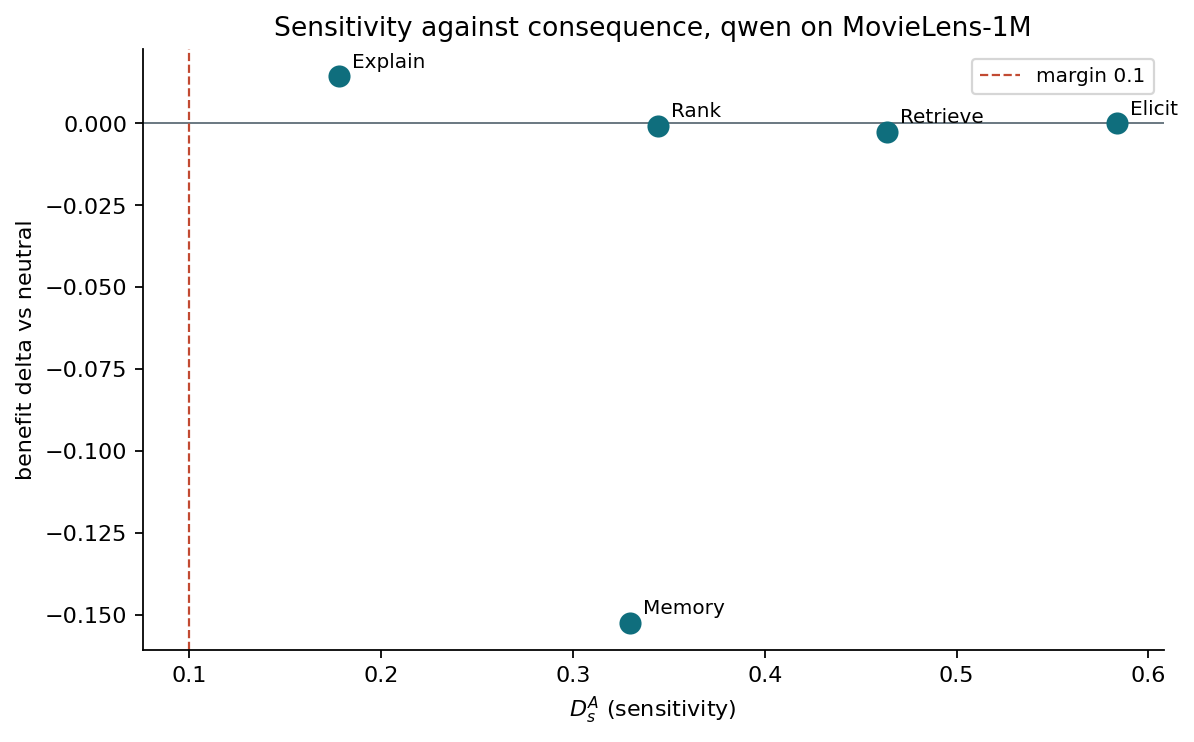

In [ ]:
# D_s^A beside the benefit delta from the held-out reference

Memory is the finding here. It carries a middling direct effect (0.330, barely above its
0.304 floor) yet the largest harm by a wide margin: benefit falls 0.1526 against the
neutral run, where no other stage moves more than 0.015. Ranking the stages by
sensitivity would put Elicit first and Memory third; ranking them by harm puts Memory
first and Elicit last.

That is the argument for keeping the reference beside `D_s^A` rather than inside it, and
it is the first time this project has shown it on a served model over real data.

## What this does and does not establish

**Established.** The estimator works on a served model but needs its noise floor: the
planted-stage effect separates from the background by +0.16 while unplanted stages sit at
-0.003. Localisation of 32.7% against 16.7% chance is above chance and far below the
84.7% a scripted policy allows. Sensitivity and harm order the stages differently.

**Not established.** Nothing here says qwen treats men and women, or any age group,
differently: the dispersion values are small and sit inside the measured jitter, and every
planted fault is an artificial unit test of the instrument. The 32.7% figure is also a
lower bound on the estimator alone, because a missed detection may be a model that
declined the planted instruction. A manipulation check, re-running after injection and
keeping only the cases where the output actually changed, would separate the two.